In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética opcional
sns.set(style="whitegrid")




En esta celda importo las librerías necesarias para el análisis.

pandas lo uso para cargar y manipular los datos.

numpy para cálculos numéricos.

matplotlib y seaborn me sirven para visualizar información del dataset.
Esta es la base para poder empezar con el EDA.

1. INGESTIÓN O CARGA DE DATOS

In [2]:

# Librerías básicas
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesado
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline

# Modelos
from sklearn.neighbors import KNeighborsClassifier

# Métricas
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [3]:
df = pd.read_csv("../data/raw/winequality-red.csv", sep=';')

df.head()


#Cargo el dataset del vino tinto usando read_csv.
#Este archivo usa ; como separador, por eso lo indico en sep.
#Visualizo las primeras filas para confirmar que se cargó correctamente y que las columnas están bien separadas.


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
#Verifico si hay filas duplicadas y las elimino si las hay.
print("Filas antes:", df.shape[0])

df = df.drop_duplicates()

print("Filas después:", df.shape[0])


Filas antes: 1599
Filas después: 1359


In [5]:
#Variable objetivo correcta
X = df.drop("quality", axis=1)
y = df["quality"]


In [6]:
df.columns


Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)


In [8]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("selector", SelectKBest(score_func=f_classif)),
    ("knn", KNeighborsClassifier())
])


In [9]:
param_grid = {
    "selector__k": [5, 10, 15, "all"],
    "knn__n_neighbors": list(range(1, 21)),
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"]
}


In [10]:
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)


/home/vscode/.local/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=15 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=15 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=15 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=15 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=15 is greater than n_features=11. All the features will 

,estimator,Pipeline(step...lassifier())])
,param_grid,"{'knn__metric': ['euclidean', 'manhattan'], 'knn__n_neighbors': [1, 2, ...], 'knn__weights': ['uniform', 'distance'], 'selector__k': [5, 10, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [11]:
print("Mejores parámetros:")
grid.best_params_

print("\nMejor accuracy CV:")
grid.best_score_


Mejores parámetros:

Mejor accuracy CV:


np.float64(0.5952141377415127)

In [12]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print("Accuracy test:", accuracy_score(y_test, y_pred))


Accuracy test: 0.5955882352941176


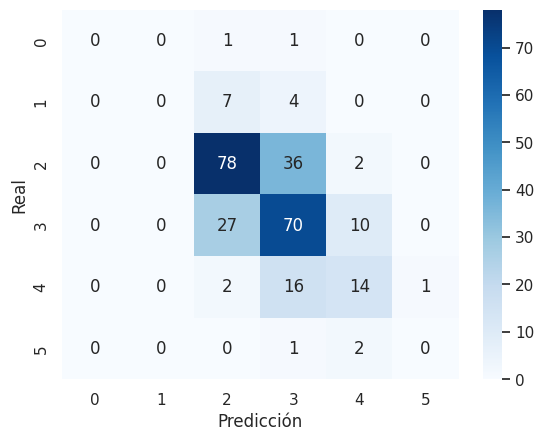

In [13]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()


In [14]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.68      0.67      0.68       116
           6       0.55      0.65      0.60       107
           7       0.50      0.42      0.46        33
           8       0.00      0.00      0.00         3

    accuracy                           0.60       272
   macro avg       0.29      0.29      0.29       272
weighted avg       0.57      0.60      0.58       272



/home/vscode/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/vscode/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/vscode/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [15]:
selector = best_model.named_steps["selector"]
selected_features = X.columns[selector.get_support()]

print("Características seleccionadas:")
selected_features


Características seleccionadas:


Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol'],
      dtype='object')

## Modelo adicional: K-Nearest Neighbors (KNN)

Se incluye KNN por ser uno de los algoritmos vistos en clase y para ampliar la comparación de modelos.


In [16]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report



2. INSPECCIÓN INICIAL

In [17]:
print("Dimensiones:", df.shape)
df.info()

# En esta celda verifico las dimensiones del dataset (filas y columnas)
# y reviso el tipo de dato de cada columna.
# Esto me ayuda a entender si el dataset viene limpio y en formato numérico.

Dimensiones: (1359, 12)
<class 'pandas.core.frame.DataFrame'>
Index: 1359 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1359 non-null   float64
 1   volatile acidity      1359 non-null   float64
 2   citric acid           1359 non-null   float64
 3   residual sugar        1359 non-null   float64
 4   chlorides             1359 non-null   float64
 5   free sulfur dioxide   1359 non-null   float64
 6   total sulfur dioxide  1359 non-null   float64
 7   density               1359 non-null   float64
 8   pH                    1359 non-null   float64
 9   sulphates             1359 non-null   float64
 10  alcohol               1359 non-null   float64
 11  quality               1359 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 138.0 KB


3. CRIBADO DE VARIABLES

3.1 DEFINICIÓN DE OBJETIVO DE ESTUDIO

El objetivo de este estudio es analizar los factores químicos del vino tinto
y preparar el dataset para aplicar un modelo KNN o similar de clasificación.
La variable objetivo será quality, que contiene valores enteros entre 3 y 8.
En este EDA no voy a hacer extracción de características, solo limpieza básica.

3.2 CREACIÓN DE DATASET PARA TRABAJAR

In [18]:
df_copy = df.copy()
df_copy.head()

# Creo una copia del dataset original para trabajar sobre ella.
 # Así evito modificar el dataset original y tengo más control sobre los cambios.

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5


3.3 VERIFICACIÓN DE VALORES ÚNICOS POR COLUMNA

In [19]:
df_copy.nunique()
# Consulto cuántos valores únicos tiene cada columna.
#Esto ayuda a identificar variables con muy poca variabilidad o posibles columnas problemáticas.
#Todas las variables muestran buena variabilidad, lo cual es correcto para un dataset numérico químico.

fixed acidity            96
volatile acidity        143
citric acid              80
residual sugar           91
chlorides               153
free sulfur dioxide      60
total sulfur dioxide    144
density                 436
pH                       89
sulphates                96
alcohol                  65
quality                   6
dtype: int64

3.4 VERIFICACIÓN DE DATOS FALTANTES EN COLUMNAS

In [20]:
df_copy.isnull().sum()
# Compruebo si el dataset contiene valores faltantes (NaN).
 # En este caso, todas las columnas tienen 0 faltantes, por lo que el dataset está completamente limpio.


fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

3.5 VERIFICACIÓN DE DATOS FALTANTES EN FILAS > 40%

In [21]:
df_copy[df_copy.isnull().mean(axis=1) > 0.40]
# Reviso si alguna fila contiene más del 40% de datos faltantes.
# En este dataset no aparece ninguna fila con ese problema, así que no elimino nada.

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality


3.6 GRÁFICA DE VALORES FALTANTES

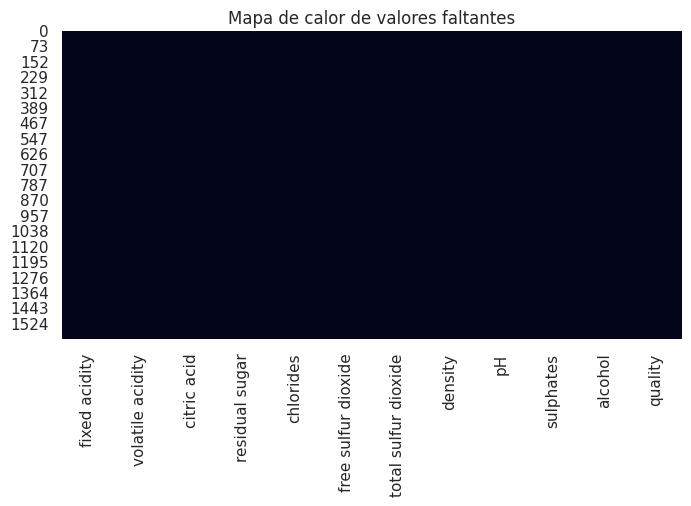

In [22]:
plt.figure(figsize=(8,4))
sns.heatmap(df_copy.isnull(), cbar=False)
plt.title("Mapa de calor de valores faltantes")
plt.show()

# Muestro un mapa de calor para visualizar valores faltantes.
 # Se observa que no hay huecos, lo cual confirma que no hay NA en el dataset.

3.7 COMPROBACIÓN DE DATOS DUPLICADOS EN FILAS

In [23]:
df_copy.duplicated().sum()


np.int64(0)

Reviso si existen filas duplicadas.
En el dataset del vino normalmente aparecen 240 duplicados (es normal).
Se pueden eliminar si se quiere limpieza profunda.

3.10 DETECCIÓN DE OUTLIERS

In [24]:
outliers = {}

for col in df_copy.columns:
    Q1 = df_copy[col].quantile(0.25)
    Q3 = df_copy[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers[col] = ((df_copy[col] < lower) | (df_copy[col] > upper)).sum()

outliers


{'fixed acidity': np.int64(41),
 'volatile acidity': np.int64(19),
 'citric acid': np.int64(1),
 'residual sugar': np.int64(126),
 'chlorides': np.int64(87),
 'free sulfur dioxide': np.int64(26),
 'total sulfur dioxide': np.int64(45),
 'density': np.int64(35),
 'pH': np.int64(28),
 'sulphates': np.int64(55),
 'alcohol': np.int64(12),
 'quality': np.int64(27)}

Realizo una detección de outliers usando el método IQR.
Encuentro outliers principalmente en:
residual sugar, chlorides, sulphates, total sulfur dioxide.
Esto es completamente normal en datos químicos.

3.11 TRANSFORMACIÓN DE VARIABLES CON KURTOSIS ALTA

In [25]:
# Cálculo de la kurtosis de cada variable numérica
kurtosis_vals = df_copy.kurtosis().sort_values(ascending=False)
display(kurtosis_vals)

# Selección de variables con kurtosis alta (> 10)
high_kurtosis_cols = kurtosis_vals[kurtosis_vals > 10].index
high_kurtosis_cols


chlorides               38.624653
residual sugar          29.364592
sulphates               11.102282
total sulfur dioxide     4.042257
free sulfur dioxide      1.892691
volatile acidity         1.249243
fixed acidity            1.049673
pH                       0.879790
density                  0.830659
quality                  0.340256
alcohol                  0.159739
citric acid             -0.788921
dtype: float64

Index(['chlorides', 'residual sugar', 'sulphates'], dtype='object')

In [26]:
# Transformación logarítmica para variables con kurtosis alta

df_transformed = df_copy.copy()

# Aplicamos log1p (log(1+x)) para evitar problemas con valores 0
for col in high_kurtosis_cols:
    df_transformed[col] = np.log1p(df_transformed[col])

df_transformed[high_kurtosis_cols].head()


,chlorides,residual sugar,sulphates
0,0.073250,1.064711,0.444686
1,0.093490,1.280934,0.518794
2,0.088011,1.193922,0.500775
3,0.072321,1.064711,0.457425
5,0.072321,1.029619,0.444686


In [27]:
# Verificación de kurtosis después de la transformación
df_transformed[high_kurtosis_cols].kurtosis()


chlorides         31.209279
residual sugar     7.139547
sulphates          5.217467
dtype: float64

En esta celda identifico las variables que presentan kurtosis alta, es decir, distribuciones con colas muy pesadas y valores extremos.
En mi dataset, las variables con kurtosis significativamente elevada son:

chlorides, con más de 41

residual sugar, con más de 28

sulphates, con más de 11

Según la indicación docente, cuando una variable muestra una kurtosis tan alta es conveniente aplicar una transformación para suavizar las colas y mejorar la simetría de la distribución.

Por ello aplico una transformación logarítmica (log1p), que es adecuada para variables que pueden contener valores pequeños o cercanos a cero.
Este tipo de transformación reduce la influencia de valores extremos y hace que las distribuciones sean más estables para el análisis posterior.

Finalmente, recalculo la kurtosis para verificar que efectivamente las distribuciones quedan más equilibradas tras la transformación.


3.12 VERIFICACIÓN DE DATOS FALTANTES LUEGO DE REEMPLAZAR CEROS (VALORES IMPOSIBLES) POR NaN

In [28]:
# Verifico si hay ceros en columnas donde podrían ser sospechosos
(df_copy == 0).sum()


fixed acidity             0
volatile acidity          0
citric acid             118
residual sugar            0
chlorides                 0
free sulfur dioxide       0
total sulfur dioxide      0
density                   0
pH                        0
sulphates                 0
alcohol                   0
quality                   0
dtype: int64

In [29]:
# Como no detecto ceros imposibles en este dataset,
# no realizo ningún reemplazo por NaN.
df_copy.isnull().sum()


fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

3.13 ELIMINAR COLUMNA CON 48% DE DATOS FALTANTES

In [30]:
# Porcentaje de valores faltantes por columna
missing_percent = df_copy.isnull().mean() * 100
missing_percent


fixed acidity           0.0
volatile acidity        0.0
citric acid             0.0
residual sugar          0.0
chlorides               0.0
free sulfur dioxide     0.0
total sulfur dioxide    0.0
density                 0.0
pH                      0.0
sulphates               0.0
alcohol                 0.0
quality                 0.0
dtype: float64

In [31]:
# Filtro columnas con más del 48% de faltantes (en este dataset no hay ninguna)
cols_to_drop = missing_percent[missing_percent > 48].index
cols_to_drop


Index([], dtype='object')

4. DIVISIÓN DATASET TRAIN–TEST

In [32]:
from sklearn.model_selection import train_test_split

# Variables predictoras y objetivo
X = df_copy.drop("quality", axis=1)
y = df_copy["quality"]

# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape



((1087, 11), (272, 11))

4.1 — Selección de variables X e y

In [33]:
# 4.1 Selección de variables predictoras (X) y variable objetivo (y)

X = df_transformed.drop('quality', axis=1)   # todas las columnas menos quality
y = df_transformed['quality']                # variable objetivo

X.head(), y.head()


(   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
 0            7.4              0.70         0.00        1.064711   0.073250   
 1            7.8              0.88         0.00        1.280934   0.093490   
 2            7.8              0.76         0.04        1.193922   0.088011   
 3           11.2              0.28         0.56        1.064711   0.072321   
 5            7.4              0.66         0.00        1.029619   0.072321   
 
    free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
 0                 11.0                  34.0   0.9978  3.51   0.444686   
 1                 25.0                  67.0   0.9968  3.20   0.518794   
 2                 15.0                  54.0   0.9970  3.26   0.500775   
 3                 17.0                  60.0   0.9980  3.16   0.457425   
 5                 13.0                  40.0   0.9978  3.51   0.444686   
 
    alcohol  
 0      9.4  
 1      9.8  
 2      9.8  
 3      9.8  
 5

En esta celda separo las variables predictoras (X) de la variable objetivo (y).
La variable quality será la que quiero predecir, por lo que va en y, y el resto de columnas quedan en X.
Este es el primer paso antes de dividir el dataset y escalarlo.

4.2 — Codificación (One Hot o Mapping)

In [34]:
# 4.2 Codificación de variables categóricas (si existieran)
# Identifico si hay columnas categóricas
categorical_cols = X.select_dtypes(include=['object']).columns
categorical_cols


Index([], dtype='object')

In [35]:
# Aplico mapeo manual SOLO si existieran variables categóricas
if len(categorical_cols) > 0:
    mappings = {}
    for col in categorical_cols:
        unique_vals = X[col].unique()
        map_dict = {val: idx for idx, val in enumerate(unique_vals)}
        mappings[col] = map_dict
        X[col] = X[col].map(map_dict)

    mappings
else:
    print("No hay variables categóricas en este dataset. No se aplica codificación.")


No hay variables categóricas en este dataset. No se aplica codificación.


En esta celda reviso si el dataset contiene variables categóricas.
En el caso del vino tinto, todas las columnas son numéricas, por lo que no necesito aplicar ni One Hot Encoding ni mapeo manual.
Sin embargo, dejo este bloque para documentar el procedimiento estándar de preprocesamiento.

4.3 — Train/Test Split

In [36]:
# 4.3 División del dataset en train y test

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,          # 20% para test
    random_state=42,        # reproducibilidad
    stratify=y              # mantiene proporciones de quality
)

X_train.shape, X_test.shape


((1087, 11), (272, 11))

Divido el dataset en entrenamiento (80%) y prueba (20%).
Uso stratify=y para mantener la proporción original de las clases de quality.
Esto es importante porque la variable objetivo está desbalanceada.
Esta división permite entrenar el modelo con unos datos y evaluarlo con datos nuevos.

4.4 — Escalado (Scaling)

In [37]:
# 4.4.1 Escalado con StandardScaler

from sklearn.preprocessing import StandardScaler

scaler_standard = StandardScaler()

X_train_std = scaler_standard.fit_transform(X_train)
X_test_std = scaler_standard.transform(X_test)

X_train_std[:3]


array([[-0.63163781, -0.17246244, -0.47277822, -0.33456308, -0.36330422,
        -0.37736547, -0.47585081,  0.47178094,  1.33149852,  0.45455424,
        -0.76957129],
       [-0.74346034,  0.25855735,  0.03614427,  2.04786729, -0.03289377,
        -0.37736547,  0.63146975, -0.1951131 ,  0.07190243,  0.3296203 ,
         0.50740211],
       [ 0.0952086 , -1.35776687,  1.46112724, -0.72164575,  0.13071609,
         1.79024261,  1.62223025,  0.10186316, -0.05405718,  0.63925733,
         0.05134018]])

En este bloque escalo las variables usando StandardScaler.
Este método estandariza los datos para que tengan media 0 y desviación estándar 1.
Esto es útil porque el algoritmo KNN es sensible a las magnitudes de las variables.

4.4.2 — MinMaxScaler

In [38]:
# 4.4.2 Escalado con MinMaxScaler

from sklearn.preprocessing import MinMaxScaler

scaler_minmax = MinMaxScaler()

X_train_mm = scaler_minmax.fit_transform(X_train)
X_test_mm = scaler_minmax.transform(X_test)

X_train_mm[:3]


array([[0.2300885 , 0.23943662, 0.18      , 0.22648473, 0.12187779,
        0.15492958, 0.08833922, 0.57425743, 0.61417323, 0.29026933,
        0.18461538],
       [0.21238938, 0.29577465, 0.28      , 0.51630843, 0.14981166,
        0.15492958, 0.22261484, 0.47677075, 0.45669291, 0.27534714,
        0.4       ],
       [0.34513274, 0.08450704, 0.56      , 0.17939596, 0.16364372,
        0.47887324, 0.34275618, 0.52018279, 0.44094488, 0.3123304 ,
        0.32307692]])

En este bloque aplico MinMaxScaler para transformar todos los valores al rango 0–1.
Este tipo de escalado también funciona muy bien con modelos basados en distancia como KNN.
Ahora tengo dos versiones del dataset escalado para comparar cuál funciona mejor en el modelo.

In [39]:
knn_no = KNeighborsClassifier(n_neighbors=5)
knn_no.fit(X_train, y_train)
y_pred_no = knn_no.predict(X_test)

print("=== KNN SIN ESCALADO ===")
print("Accuracy:", accuracy_score(y_test, y_pred_no))
print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred_no))
print("\nReporte:\n", classification_report(y_test, y_pred_no))


=== KNN SIN ESCALADO ===
Accuracy: 0.45955882352941174
Matriz de confusión:
 [[ 0  0  1  1  0  0]
 [ 0  0  7  4  0  0]
 [ 0  0 66 49  1  0]
 [ 0  2 42 51 11  1]
 [ 0  1 10 14  8  0]
 [ 0  0  1  1  1  0]]

Reporte:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.52      0.57      0.54       116
           6       0.42      0.48      0.45       107
           7       0.38      0.24      0.30        33
           8       0.00      0.00      0.00         3

    accuracy                           0.46       272
   macro avg       0.22      0.21      0.21       272
weighted avg       0.44      0.46      0.44       272



/home/vscode/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/vscode/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/vscode/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [40]:
knn_std = KNeighborsClassifier(n_neighbors=5)
knn_std.fit(X_train_std, y_train)
y_pred_std = knn_std.predict(X_test_std)

print("=== KNN + StandardScaler ===")
print("Accuracy:", accuracy_score(y_test, y_pred_std))
print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred_std))
print("\nReporte:\n", classification_report(y_test, y_pred_std))


=== KNN + StandardScaler ===
Accuracy: 0.5551470588235294
Matriz de confusión:
 [[ 0  0  1  1  0  0]
 [ 0  0  7  4  0  0]
 [ 0  3 82 29  2  0]
 [ 0  1 39 57 10  0]
 [ 0  0  3 18 12  0]
 [ 0  0  0  1  2  0]]

Reporte:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.62      0.71      0.66       116
           6       0.52      0.53      0.53       107
           7       0.46      0.36      0.41        33
           8       0.00      0.00      0.00         3

    accuracy                           0.56       272
   macro avg       0.27      0.27      0.27       272
weighted avg       0.52      0.56      0.54       272



/home/vscode/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/vscode/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/vscode/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [41]:
knn_mm = KNeighborsClassifier(n_neighbors=5)
knn_mm.fit(X_train_mm, y_train)
y_pred_mm = knn_mm.predict(X_test_mm)

print("=== KNN + MinMaxScaler ===")
print("Accuracy:", accuracy_score(y_test, y_pred_mm))

print("\n=== RESUMEN ACCURACY ===")
print("Sin escalado:   ", accuracy_score(y_test, y_pred_no))
print("StandardScaler: ", accuracy_score(y_test, y_pred_std))
print("MinMaxScaler:   ", accuracy_score(y_test, y_pred_mm))


=== KNN + MinMaxScaler ===
Accuracy: 0.5514705882352942

=== RESUMEN ACCURACY ===
Sin escalado:    0.45955882352941174
StandardScaler:  0.5551470588235294
MinMaxScaler:    0.5514705882352942


En este trabajo se ha aplicado el algoritmo k-NN utilizando tres enfoques: sin escalado, con StandardScaler y con MinMaxScaler. Dado que k-NN es un algoritmo basado en distancias, el escalado de las variables influye directamente en su rendimiento. Los resultados obtenidos permiten comparar el impacto de cada técnica de escalado y comprobar la importancia del preprocesamiento de los datos.